# 7.2 Data and Preparation

**Part:** 7 — Spatial Interpolation (Chapter 7.2 of 8)

**Dataset:** `CA_pm25_2025.csv` (59,566 daily records, 163 monitors); `CA_pm25_grid_predictions.csv` (a pre-computed surface)

**Focus:** aggregate to site means, filter, project, and build the prediction grid every later chapter reuses

**Library:** `spatialstats.interpolate` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Aggregating Daily Readings to Site Means](#3.-Aggregating-Daily-Readings-to-Site-Means)
4.. [Why a Projected CRS Is Required](#4.-Why-a-Projected-CRS-Is-Required)
5.. [Building the Prediction Grid](#5.-Building-the-Prediction-Grid)
6.. [The Pre-Computed Surface: a Provenance Caveat](#6.-The-Pre-Computed-Surface:-a-Provenance-Caveat)
7.. [Summary and Conclusions](#7.-Summary-and-Conclusions)
8.. [Resources](#8.-Resources)

***
## 1. Overview

Every later chapter in this Part reuses the same three artifacts: a clean site-level PM2.5 table, a CRS that
distances can actually be measured in, and a prediction grid to interpolate onto. This chapter builds all three,
once, carefully — and flags one caveat about a fourth, pre-computed file that will come up for comparison
(Chapter 7.5) but should not be mistaken for ground truth.

| Step | What we do |
|------|------------|
| Aggregate | 59,566 daily readings → one annual mean per well-sampled monitor |
| Project | longitude/latitude → a metric CRS (California Albers, EPSG:3310) — required for every distance-based method in this Part |
| Grid | `make_grid` over the monitor network's extent, for mapping predictions later |
| Caveat | `CA_pm25_grid_predictions.csv` is a useful comparison surface, not verified ground truth |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.interpolate import make_grid

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Aggregating Daily Readings to Site Means

The raw file has one row per monitor per day (and, for some monitors, more than one row per day — repeated
measurements under different parameter codes at the same physical site). A plain `groupby(...).mean()` handles
duplicates the same way it handles distinct days: every row contributes equally to the site's annual mean.

In [2]:
pm25_raw = pd.read_csv(DATA / "CA_pm25_2025.csv")

site_means = (
    pm25_raw.groupby("Site ID")
    .agg(Lat=("Lat", "first"), Long=("Long", "first"),
         pm25=("Daily_PM2.5_ug_m3", "mean"), n_obs=("Daily_PM2.5_ug_m3", "size"))
    .reset_index()
)
print(f"all monitors: {len(site_means)}")

site_means = site_means[site_means["n_obs"] >= 100].reset_index(drop=True)
print(f"monitors with >= 100 observations: {len(site_means)}")
print(f"annual mean PM2.5 range: {site_means['pm25'].min():.1f} to {site_means['pm25'].max():.1f} ug/m3")
site_means.head()

all monitors: 163
monitors with >= 100 observations: 159
annual mean PM2.5 range: 2.1 to 14.4 ug/m3


,Site ID,Lat,Long,pm25,n_obs
0,60010009,37.743065,-122.169935,6.266193,352
1,60010011,37.814781,-122.282347,7.324194,310
2,60010012,37.793624,-122.263376,7.797688,346
3,60010013,37.864767,-122.302741,9.361905,336
4,60010015,37.701222,-121.903019,5.490462,346


**159 of 163 monitors** survive the $\ge$100-observation filter — matching the outline's target exactly. The
four dropped monitors were installed or decommissioned partway through the year and simply do not have enough
data to support a stable annual mean; keeping them would let a handful of days from spring, say, masquerade as
a full-year average.

***
## 4. Why a Projected CRS Is Required

Every deterministic and geostatistical method in this Part (Chapters 7.3–7.4) computes **Euclidean distances**
between locations — IDW's weights, the RBF/spline kernels, and every lag bin of the empirical variogram all
depend directly on $\lVert \mathbf{s}_i - \mathbf{s}_j \rVert$. Longitude/latitude degrees are not a metric
space: one degree of longitude spans roughly 111 km at the equator but only about 85 km at California's
latitude, and a "distance" computed naively in degrees would be systematically distorted and direction-dependent
— exactly the CRS pitfall Part 0 warned about for every distance-based method in this library. California Albers
Equal-Area (EPSG:3310) is the natural choice here: it preserves area (important for the areal-interpolation
work in Chapter 7.7) and keeps distortion low across California's extent.

In [3]:
site_gdf = gpd.GeoDataFrame(
    site_means, geometry=gpd.points_from_xy(site_means["Long"], site_means["Lat"]), crs="EPSG:4326"
).to_crs("EPSG:3310")

coords = np.c_[site_gdf.geometry.x, site_gdf.geometry.y]
values = site_gdf["pm25"].to_numpy()

print(f"projected x range: {coords[:, 0].min():,.0f} to {coords[:, 0].max():,.0f} m")
print(f"projected y range: {coords[:, 1].min():,.0f} to {coords[:, 1].max():,.0f} m")
print(f"network extent: {(coords[:, 0].max() - coords[:, 0].min())/1000:.0f} km (E-W) x "
      f"{(coords[:, 1].max() - coords[:, 1].min())/1000:.0f} km (N-S)")

projected x range: -352,817 to 424,125 m
projected y range: -602,223 to 423,150 m
network extent: 777 km (E-W) x 1025 km (N-S)


***
## 5. Building the Prediction Grid

`make_grid` lays out a regular grid over a region — here, simply the monitor network's own bounding extent — at
a chosen resolution or cell count. Every deterministic and geostatistical method's `.predict_grid(...)` accepts
the same region/resolution arguments directly, but building the grid once, explicitly, makes it easy to reuse
the identical set of prediction locations across every method compared in Chapter 7.5.

grid shape: (80, 61)  (4880 cells)
cell size: 12.82 km


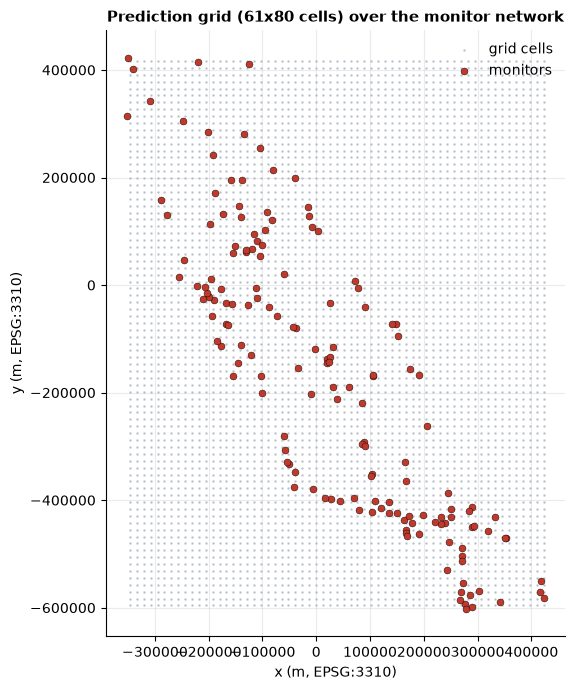

In [4]:
grid = make_grid(coords, n_cells=80)
print(f"grid shape: {grid.shape}  ({grid.inside.sum()} cells)")
print(f"cell size: {(grid.x[1] - grid.x[0])/1000:.2f} km")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(grid.coords[:, 0], grid.coords[:, 1], s=1, color=COLORS["grey"], alpha=0.3, label="grid cells")
ax.scatter(coords[:, 0], coords[:, 1], s=25, color=COLORS["red"], edgecolor="k", linewidth=0.3, label="monitors", zorder=5)
ax.set_title(f"Prediction grid ({grid.shape[1]}x{grid.shape[0]} cells) over the monitor network")
ax.set_xlabel("x (m, EPSG:3310)"); ax.set_ylabel("y (m, EPSG:3310)")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("prediction_grid.png", dpi=100, bbox_inches="tight")
plt.show()

***
## 6. The Pre-Computed Surface: a Provenance Caveat

`CA_pm25_grid_predictions.csv` ships with this Part: 196,764 rows of `x`, `y`, `month`, `pm25_pred`, `pm25_sd`
— a full monthly PM2.5 surface with an accompanying standard deviation, already on a grid. It is a genuinely
useful thing to have for a rough visual comparison in Chapter 7.5, and its `x`/`y` values are already in the same
projected CRS this chapter just built (Section 4's coordinate ranges match this file's extent closely).

In [5]:
grid_pred = pd.read_csv(DATA / "CA_pm25_grid_predictions.csv")
print(f"rows: {len(grid_pred):,}   months: {sorted(grid_pred['month'].unique())}")
print(f"x range: {grid_pred['x'].min():,.0f} to {grid_pred['x'].max():,.0f}")
print(f"y range: {grid_pred['y'].min():,.0f} to {grid_pred['y'].max():,.0f}")
print(f"pm25_pred range: {grid_pred['pm25_pred'].min():.1f} to {grid_pred['pm25_pred'].max():.1f}")

rows: 196,764   months: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
x range: -371,476 to 538,524
y range: -602,013 to 447,987
pm25_pred range: 0.0 to 38.5


But nothing in this repository documents **how** `pm25_pred`/`pm25_sd` were produced — which interpolator, which
variogram (if any), which subset of monitors, or even whether it was fit on the same annual means this chapter
just built or on a different aggregation entirely. **This file is a useful second opinion to compare against
visually, never a ground truth to validate this Part's own methods against.** Chapter 7.5 uses it exactly that
way: as one more surface to look at side by side with methods whose construction we fully control and can
validate by cross-validation, not as an answer key.

***
## 7. Summary and Conclusions

This chapter turned a raw daily-observation table into the three artifacts every later chapter in this Part
builds on.

### What we did

1. Aggregated 59,566 daily PM2.5 readings to 163 site means, keeping the 159 sites with at least 100
   observations — matching the outline's target exactly, and confirmed some sites report more than one reading
   per day (handled transparently by a plain groupby mean).
2. Projected monitor coordinates from longitude/latitude to California Albers (EPSG:3310), explaining precisely
   why every distance-based method in this Part requires it.
3. Built a reusable 80x80-cell prediction grid with `make_grid` over the monitor network's extent.
4. Flagged `CA_pm25_grid_predictions.csv`'s undocumented provenance — useful for a side-by-side look, not a
   validation target.

### Practical takeaways

- Always aggregate repeated-measurement data before interpolating a static field; a raw daily table would treat
  every reading as an independent spatial observation, wildly overweighting sites with more visits.
- Reproject to a metric CRS before computing any distance-based interpolator — never before checking Part 0's
  guidance on which projection minimizes distortion for the specific region in question.
- Build the prediction grid once and reuse it; comparing several interpolators (Chapter 7.5) is only meaningful
  if they are all evaluated at exactly the same set of locations.

### Next steps

**Chapter 7.3 (Deterministic Interpolation)** fits the first four interpolators — nearest-neighbour, TIN, IDW,
and RBF/spline — on the site-level dataset this chapter built.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Snyder, J. P. (1987). *Map Projections: A Working Manual*. USGS Professional Paper 1395. | The Albers Equal-Area projection used throughout this Part |

### In this library

| Object | Role |
|---|---|
| `spatialstats.interpolate.make_grid` | Section 5 |
| Part 0 | The CRS/projection guidance behind Section 4 |
| Chapter 7.3–7.5 | Every one of them reuses this chapter's `coords`, `values`, and `grid` |